# Simulation analysis

After autorunning the simulation several times,\
with different input values, lets analyze\
values, error and how reliable it really is

In [12]:
from datetime import datetime, timedelta # For days_between function
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

from astropy.time import Time
import lsst.summit.utils.butlerUtils as butlerUtils
from lsst.summit.utils.dateTime import (getDayObsEndTime, getDayObsStartTime)
from lsst.summit.utils.efdUtils import (getEfdData, makeEfdClient)

import d_testsimul

# Create the client for InfluxQL
efd_client = makeEfdClient()
butler = butlerUtils.makeDefaultButler("LSSTCam", embargo=False)

## Autorun settings

In [13]:
# Functions to fetch for the dataframes, copied from an old notebook
def timestamp_to_utc(timestamp):
    """
    Takes the timestamp in string value and
    converts it to a query readable timestamp
    
    Parameter
    ---------
    Timestamp: string (YYYY-MM-DD hh:mm:ss.ms)

    Returns:
    --------
    EFD-readable timestamp
    """
    timestamp = pd.to_datetime(str(timestamp))
    new_stamp = timestamp.value
    step = int(0.01 * 1e10)
    rounded_stamp = (new_stamp // step) * step
    timestamp = Time(pd.to_datetime(rounded_stamp), scale="utc")

    return timestamp


def days_between(start, end):
    """
    Creates a list of YYYYMMDD days for analysis
    
    Parameters:
    -----------
    start : int (YYYYMMDD)
        Start date
    end : int (YYYYMMDD)
        End date
    
    Returns:
    --------
    List with YYYYMMDD in between dates given
    """
    start_date = datetime.strptime(str(start), "%Y%m%d")
    end_date = datetime.strptime(str(end), "%Y%m%d")
    
    days = []
    current = start_date
    while current <= end_date:
        days.append(int(current.strftime("%Y%m%d")))
        current += timedelta(days=1)
    
    return days

def per_minute(df):
    """
    Take an input dataframe and groups it by minutes

    Parameter
    ---------
    df: dataframe with first column timestamp
        in format YYYY-MM-DD hh:mm:ss

    Returns:
    --------
    Grouped dataframe
    """
    out = df.copy()
    out['minute'] = out['timestamp'].dt.floor('min')         # 1 bin per minute
    num = out.select_dtypes('number').columns                # average numeric cols
    return out.groupby('minute')[num].mean()


In [14]:
# Historic analysis config
# Arbitrary days
day_start = 20260507
day_end   = 20260509

daysinbetween = days_between(day_start, day_end)
print(f"We have {len(daysinbetween)} days to analyze")

start_time =  timestamp_to_utc(getDayObsStartTime(day_start))
end_time   =  timestamp_to_utc(getDayObsEndTime(day_end))

# Fetch dataframes
df_ringss = getEfdData(
    client  = efd_client,
    topic   = 'lsst.sal.ESS.logevent_ringssMeasurement',
    columns = ['fwhmFree', 'fwhmScintillation', 
                'fwhmSector', 'wind', 'flux'],
    begin   = start_time,
    end     = end_time
                        )

df_dimm= getEfdData(
    client  = efd_client,
    topic   = 'lsst.sal.DIMM.logevent_dimmMeasurement',
    columns = ['fwhm', 'r0', 'flux'],
    begin   = start_time,
    end     = end_time,
                )

# Reset EFD timestamp index into a normal column
df_ringss = df_ringss.reset_index()
df_ringss = df_ringss.rename(columns={'index':'timestamp'})
df_dimm = df_dimm.reset_index()
df_dimm = df_dimm.rename(columns={'index':'timestamp'})

# Group together by each minute both dataframes
ringss_min = per_minute(df_ringss)
dimm_min   = per_minute(df_dimm)

# Suffixes for shared names (e.g. 'flux' exists in both)
df_minutes = ringss_min.join(dimm_min, how='inner',
                          lsuffix='_ringss', rsuffix='_dimm')

print(f'Pachon RINGSS data points by minutes: {len(ringss_min)}')
print(f'Rubin DIMM data points by minutes: {len(dimm_min)}')
print(f'Coinciding minutes: {len(df_minutes)}')
df_minutes.head()

We have 3 days to analyze
Pachon RINGSS data points by minutes: 2152
Rubin DIMM data points by minutes: 1141
Coinciding minutes: 1123


,fwhmFree,fwhmScintillation,fwhmSector,wind,flux_ringss,fwhm,r0,flux_dimm
minute,,,,,,,,
2026-05-08 01:03:00+00:00,2.1395,2.3200,2.9680,12.535,104130.0,1.903509,-1.0,0.0
2026-05-08 01:04:00+00:00,2.0240,2.1545,2.7725,12.825,103845.0,2.000315,-1.0,0.0
2026-05-08 01:05:00+00:00,2.0160,2.1760,2.7615,14.920,103770.0,1.934997,-1.0,0.0
2026-05-08 01:06:00+00:00,2.3170,2.4890,3.2080,15.200,104600.0,1.887345,-1.0,0.0
2026-05-08 01:07:00+00:00,2.1000,2.2855,2.8935,15.525,104445.0,2.071322,-1.0,0.0


### Autorun

In [33]:
# Run d_testsimul with the OBSERVED conditions (RINGSS sector seeing + wind)
# input the observed reference values onto that same row as obs_*
out = 'testsimul_results.csv'

max_runs = int(len(df_minutes) / 2) # Limit for less time
n = len(df_minutes) if max_runs is None else min(max_runs, len(df_minutes))

print(f'Running {n} simulations')
run = (n * 95 / 60) # Each run takes around 95 seconds
if run > 90:
    print(f'Estimated {run/60:.1f} hours')
else:
    print(f'Estimated {run:.1f} minutes')
    
    
times = []
step = max(1, n // 10)  # print progress every ~10% of the runs
for i in range(n):
    ringss_sector = round(df_minutes['fwhmSector'].iloc[i], 3)
    wind          = round(df_minutes['wind'].iloc[i], 3)
    dimm_fwhm     = round(df_minutes['fwhm'].iloc[i], 3)
    seed0 = int(np.random.SeedSequence().generate_state(1, dtype=np.uint32)[0])

    # Run the simulation with observed sector seeing and wind
    t0 = time.time()
    d_testsimul.main(['--seeing', f'{ringss_sector}', '--wind', f'{wind}',
                      '--seed0', f'{seed0}', '--verbose', '', '--display', ''])  # verb/display off
    secs = round(time.time() - t0, 1)
    times.append(secs)

    # Append observed reference values to the row d_testsimul just wrote
    df_csv = pd.read_csv(out)
    obs_vals = {
        'obs_fwhmSector':        ringss_sector,
        'obs_fwhmFree':          df_minutes['fwhmFree'].iloc[i],
        'obs_fwhmScintillation': df_minutes['fwhmScintillation'].iloc[i],
        'obs_wind':              wind,
        'obs_fwhmDIMM':         dimm_fwhm,
                }
    for col, val in obs_vals.items():
        df_csv.loc[df_csv.index[-1], col] = val
    df_csv.to_csv(out, index=False)

    if i % step == 0 or i == n - 1:
        print(f'Sim {i}/{n} with Seeing: {ringss_sector}" and Wind: {wind} m/s in {secs}s')

if np.sum(times) > 90:
    print(f'\nDone! {n} runs appended to {out} in {np.sum(times) / 3600:.1f} hours.')
else: 
    print(f'\nDone! {n} runs appended to {out} in {np.sum(times) / 60:.1f} min.')

Running 561 simulations
Estimated 14.8 hours
Sim 0/561 with Seeing: 2.968" and Wind: 12.535 m/s in 90.8s
Sim 56/561 with Seeing: 3.363" and Wind: 12.41 m/s in 90.4s
Sim 112/561 with Seeing: 4.312" and Wind: 10.66 m/s in 88.5s
Sim 168/561 with Seeing: 2.429" and Wind: 14.66 m/s in 88.7s
Sim 224/561 with Seeing: 3.358" and Wind: 12.29 m/s in 88.3s
Sim 280/561 with Seeing: 2.41" and Wind: 12.74 m/s in 88.8s
Sim 336/561 with Seeing: 2.884" and Wind: 13.335 m/s in 88.8s
Sim 392/561 with Seeing: 3.4" and Wind: 13.56 m/s in 88.3s
Sim 448/561 with Seeing: 2.464" and Wind: 12.405 m/s in 88.5s
Sim 504/561 with Seeing: 1.684" and Wind: 14.76 m/s in 87.9s
Sim 560/561 with Seeing: 1.938" and Wind: 14.645 m/s in 88.7s

Done. 561 runs appended to testsimul_results.csv in 831.5 min


## Analysis

In [42]:
df_results = pd.read_csv('testsimul_results.csv')
print(f'{len(df_results)} runs, {len(df_results.columns)} columns')

561 runs, 132 columns


In [45]:
# Drop outliers
max_see = 4  # arcsec
df_results = df_results[df_results['input_seeing_arcsec'] <= max_see]
print(f'Dropped outliers, {len(df_results)} rows remain')

Dropped outliers, 538 rows remain


### Seeing vs Seeing

In [ ]:
#Curve fitting for seeings

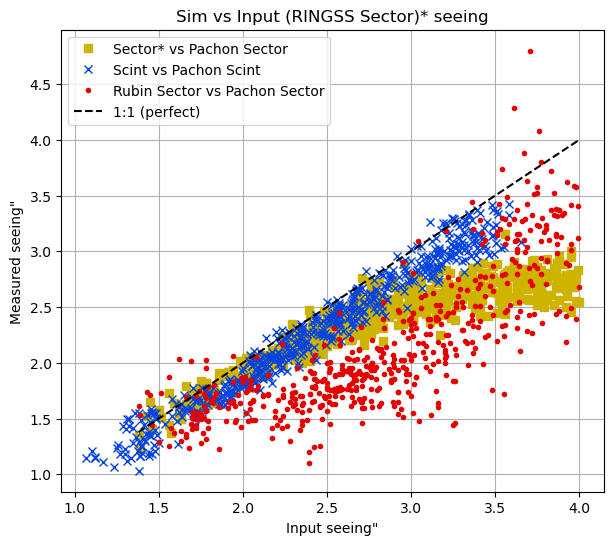

<Figure size 640x480 with 0 Axes>

In [76]:
# Measured seeing vs. input seeing
plt.figure(figsize=(7, 6))
#plt.plot(df_results['input_seeing_arcsec'], df_results['see_arcsec'],  'o', label='Scint vs Pachon Sector')

plt.plot(df_results['input_seeing_arcsec'], df_results['see2_arcsec'], 
         's', color='xkcd:mustard', label='Sector* vs Pachon Sector')

plt.plot(df_results['see_arcsec'], df_results['obs_fwhmScintillation'], 
         'x', color='xkcd:blue', label='Scint vs Pachon Scint')

plt.plot(df_results['input_seeing_arcsec'], df_results['obs_fwhmDIMM'], 
         '.', color='xkcd:red', label='Rubin Sector vs Pachon Sector')

lims = [df_results['input_seeing_arcsec'].min(), int(df_results['input_seeing_arcsec'].min()) + 3]
plt.plot(lims, lims, 'k--', label='1:1 (perfect)')

plt.xlabel('Input seeing"')
plt.ylabel('Measured seeing"')
plt.title('Sim vs Input (RINGSS Sector)* seeing')
plt.legend()
plt.grid(True)
plt.show()

### Wind vs Wind

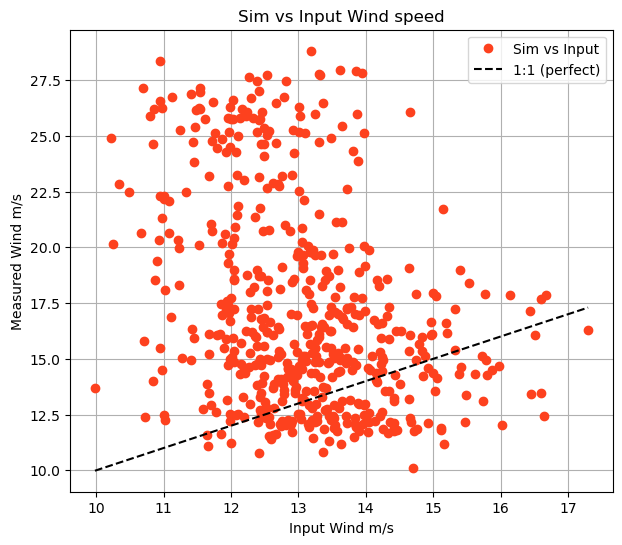

<Figure size 640x480 with 0 Axes>

In [58]:
# Measured seeing vs. input seeing
plt.figure(figsize=(7, 6))
plt.plot(df_results['input_wind_ms'], df_results['wind'], 'o', color='xkcd:orange red', label='Sim vs Input')
#plt.plot(df_results['input_wind_ms'], df_results['obs_wind'],  'x', label='1:1')

lims = [df_results['input_wind_ms'].min(), df_results['input_wind_ms'].max()]
plt.plot(lims, lims, 'k--', label='1:1 (perfect)')

plt.xlabel('Input Wind m/s')
plt.ylabel('Measured Wind m/s')
plt.title('Sim vs Input Wind speed')
plt.legend()
plt.grid(True)
plt.show()
plt.clf()

### Seeing vs Wind

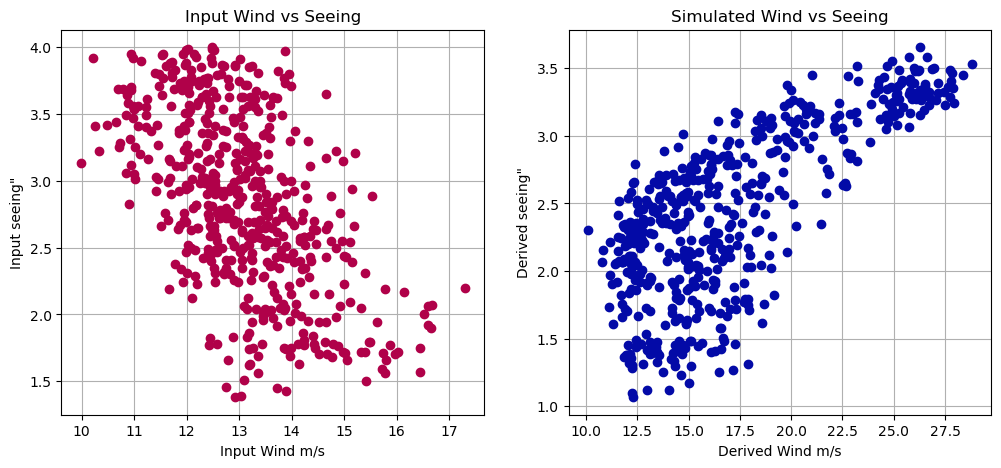

In [69]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(df_results['input_wind_ms'], df_results['input_seeing_arcsec'], 'o', color='xkcd:raspberry')
ax1.set_xlabel('Input Wind m/s')
ax1.set_ylabel('Input seeing"')
ax1.set_title('Input Wind vs Seeing')
ax1.grid(True)

ax2.plot(df_results['wind'], df_results['see_arcsec'], 'o', color='xkcd:cobalt blue')
ax2.set_xlabel('Derived Wind m/s')
ax2.set_ylabel('Derived seeing"')
ax2.set_title('Simulated Wind vs Seeing')
ax2.grid(True)

plt.show()

### Angular power spectrum

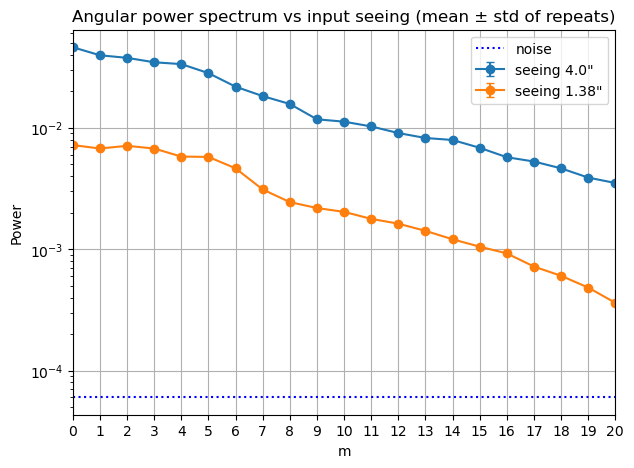

In [47]:
# Angular power spectrum (same plot as d_statmom / d_testsimul)
m = np.arange(21)                                   # angular frequency axis
power_cols = [f'power_m_{j}' for j in m]

# mean and std of each power_m across the repeated runs at each input seeing
grp  = df_results.groupby('input_seeing_arcsec')[power_cols]
mean = grp.mean()
std  = grp.std().fillna(0.0)                        # 0 if a seeing has a single run

# pick a few seeing values spanning the range
seeing = sorted(df_results['input_seeing_arcsec'].unique())
selected = [seeing[-1], seeing[0]]

plt.figure(figsize=(7, 5))
for s in selected:
    y   = mean.loc[s].to_numpy(dtype=float)
    err = std.loc[s].to_numpy(dtype=float)
    plt.errorbar(m, np.maximum(y, 1e-12), yerr=err, marker='o', capsize=3,
                 label=f'seeing {s}\"')

# shared noise floor (mean anoise over all runs)
plt.axhline(max(float(df_results['anoise'].mean()), 1e-12), ls=':', color='b', label='noise')
plt.yscale('log')
plt.xlim(0, 20)
plt.xticks(np.arange(0, 21, 1))
plt.xlabel('m')
plt.ylabel('Power')
plt.title('Angular power spectrum vs input seeing (mean \u00b1 std of repeats)')
plt.legend()
plt.grid(True)
plt.show()
